# The Prophet Model for Forecasting Rat Sightings in Manhattan

In [91]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [92]:
from prophet import Prophet
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
import matplotlib.pyplot as plt
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

## Preparing the Data for Prophet

In [93]:
df = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs.csv')
df['created_date'] = pd.to_datetime(df['created_date']) 
df = df[df['borough']=='MANHATTAN']
full_dates = pd.date_range('2020-01-01', '2025-12-31', freq='D')
full_index = pd.MultiIndex.from_product([['MANHATTAN'], full_dates], names=['borough', 'created_date'])
df = df.set_index(['borough', 'created_date']).reindex(full_index).fillna({'count': 0}).reset_index()
df['count'] = df['count'].astype(int)
df.drop(columns=['borough'], inplace=True)
df = df.rename(columns = {'created_date' : 'ds', 'count':'y'})

We then make a dataframe which has all of the federal holidays in the US.

In [94]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-01", end="2025-12-31")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

## Some hyperparameter tuning

### Warning!! The hyperparameter tuning here needs to be changed since it is tuning using all of the data!

In [95]:
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
    'seasonality_prior_scale': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(df)  # Fit model with given params
    df_cv = cross_validation(m, horizon='365 days')
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses

best_params = all_params[np.argmin(rmses)]

print(best_params)

12:13:56 - cmdstanpy - INFO - Chain [1] start processing
12:13:56 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

12:13:57 - cmdstanpy - INFO - Chain [1] start processing
12:13:57 - cmdstanpy - INFO - Chain [1] done processing
12:13:57 - cmdstanpy - INFO - Chain [1] start processing
12:13:57 - cmdstanpy - INFO - Chain [1] done processing
12:13:58 - cmdstanpy - INFO - Chain [1] start processing
12:13:58 - cmdstanpy - INFO - Chain [1] done processing
12:13:59 - cmdstanpy - INFO - Chain [1] start processing
12:13:59 - cmdstanpy - INFO - Chain [1] done processing
12:13:59 - cmdstanpy - INFO - Chain [1] start processing
12:14:00 - cmdstanpy - INFO - Chain [1] done processing
12:14:00 - cmdstanpy - INFO - Chain [1] start processing
12:14:01 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

12:14:01 - cmdstanpy - INFO - Chain [1] start processing
12:14:01 - cmdstanpy - INFO - Chain [1] done processing
12:14:01 - cmdstanpy - INFO - Chain [1] start processing
12:14:01 - cmdstanpy - INFO - Chain [1] done processing
12:14:02 - cmdstanpy - INFO - Chain [1] start processing
12:14:02 - cmdstanpy - INFO - Chain [1] done processing
12:14:03 - cmdstanpy - INFO - Chain [1] start processing
12:14:03 - cmdstanpy - INFO - Chain [1] done processing
12:14:03 - cmdstanpy - INFO - Chain [1] start processing
12:14:03 - cmdstanpy - INFO - Chain [1] done processing
12:14:04 - cmdstanpy - INFO - Chain [1] start processing
12:14:05 - cmdstanpy - INFO - Chain [1] done processing


...

  0%|          | 0/5 [00:00<?, ?it/s]

12:16:42 - cmdstanpy - INFO - Chain [1] start processing
12:16:42 - cmdstanpy - INFO - Chain [1] done processing
12:16:43 - cmdstanpy - INFO - Chain [1] start processing
12:16:43 - cmdstanpy - INFO - Chain [1] done processing
12:16:43 - cmdstanpy - INFO - Chain [1] start processing
12:16:44 - cmdstanpy - INFO - Chain [1] done processing
12:16:44 - cmdstanpy - INFO - Chain [1] start processing
12:16:45 - cmdstanpy - INFO - Chain [1] done processing
12:16:45 - cmdstanpy - INFO - Chain [1] start processing
12:16:46 - cmdstanpy - INFO - Chain [1] done processing
12:16:47 - cmdstanpy - INFO - Chain [1] start processing
12:16:47 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

12:16:47 - cmdstanpy - INFO - Chain [1] start processing
12:16:48 - cmdstanpy - INFO - Chain [1] done processing
12:16:48 - cmdstanpy - INFO - Chain [1] start processing
12:16:49 - cmdstanpy - INFO - Chain [1] done processing
12:16:49 - cmdstanpy - INFO - Chain [1] start processing
12:16:51 - cmdstanpy - INFO - Chain [1] done processing
12:16:51 - cmdstanpy - INFO - Chain [1] start processing
12:16:52 - cmdstanpy - INFO - Chain [1] done processing
12:16:53 - cmdstanpy - INFO - Chain [1] start processing
12:16:54 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}


In [96]:
best_params

{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}

## Fitting the Prophet Model

12:16:54 - cmdstanpy - INFO - Chain [1] start processing
12:16:54 - cmdstanpy - INFO - Chain [1] done processing


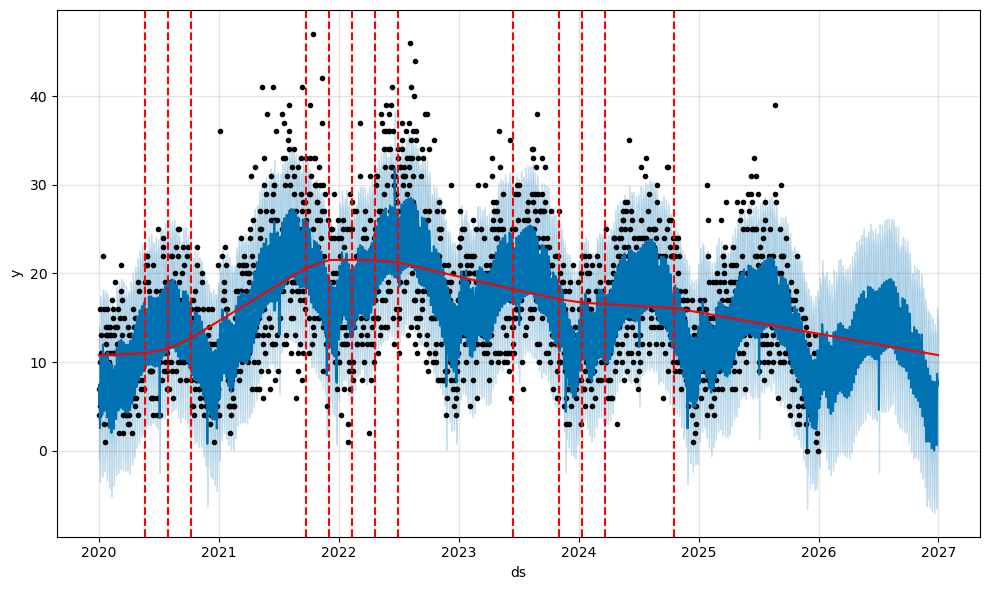

In [97]:
m = Prophet(holidays=holidays,
            changepoint_prior_scale = best_params['changepoint_prior_scale'],
            seasonality_prior_scale = best_params['seasonality_prior_scale'])
m.add_country_holidays(country_name='US')
m.fit(df)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
fig1 = m.plot(forecast)
a = add_changepoints_to_plot(fig1.gca(), m, forecast)

## Model Evaluation via Train-Test Split 80/20 

In [98]:
# Determine the split index
split_idx = int(len(df) * 0.8)  # 80% train, 20% test

df_train = df.iloc[:split_idx+1].copy()
df_test = df.iloc[split_idx+1:].copy()
m = Prophet(holidays=holidays,
            changepoint_prior_scale = best_params['changepoint_prior_scale'],
            seasonality_prior_scale = best_params['seasonality_prior_scale'])
m.add_country_holidays(country_name='US')
m.fit(df_train)
future = df_test[['ds']].copy()
forecast = m.predict(future)

rmse = np.sqrt(mean_squared_error(df_test['y'], forecast['yhat']))
print("Test RMSE:", rmse)

mae = mean_absolute_percentage_error(df_test['y'], forecast['yhat'])
print("Test MAE:", mae)

12:16:56 - cmdstanpy - INFO - Chain [1] start processing
12:16:56 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 4.986661240275788
Test MAE: 124128446386677.23


## Parameters for Cross-Validation

In [155]:
cv_period = '14 days'

forecast_horizon = '14 days'

init_days = '1558 days' # 1996 should be the right one...isn't working because we fit the model on df_train...

## Cross-Validation for Prophet

In [147]:
df_cv = cross_validation(m, 
                         initial=init_days, 
                         period=cv_period, 
                         horizon = forecast_horizon)

  0%|          | 0/13 [00:00<?, ?it/s]

12:31:29 - cmdstanpy - INFO - Chain [1] start processing
12:31:30 - cmdstanpy - INFO - Chain [1] done processing
12:31:30 - cmdstanpy - INFO - Chain [1] start processing
12:31:30 - cmdstanpy - INFO - Chain [1] done processing
12:31:30 - cmdstanpy - INFO - Chain [1] start processing
12:31:30 - cmdstanpy - INFO - Chain [1] done processing
12:31:31 - cmdstanpy - INFO - Chain [1] start processing
12:31:31 - cmdstanpy - INFO - Chain [1] done processing
12:31:31 - cmdstanpy - INFO - Chain [1] start processing
12:31:31 - cmdstanpy - INFO - Chain [1] done processing
12:31:32 - cmdstanpy - INFO - Chain [1] start processing
12:31:32 - cmdstanpy - INFO - Chain [1] done processing
12:31:32 - cmdstanpy - INFO - Chain [1] start processing
12:31:32 - cmdstanpy - INFO - Chain [1] done processing
12:31:32 - cmdstanpy - INFO - Chain [1] start processing
12:31:33 - cmdstanpy - INFO - Chain [1] done processing
12:31:33 - cmdstanpy - INFO - Chain [1] start processing
12:31:33 - cmdstanpy - INFO - Chain [1]

KeyboardInterrupt: 

In [ ]:
df_p = performance_metrics(df_cv)
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,2 days,26.508886,5.148678,4.095087,0.189138,0.140693,0.198085,0.944444
1,3 days,16.503984,4.062510,3.017870,0.138667,0.115875,0.141524,0.923077
2,4 days,22.311103,4.723463,3.616838,0.217052,0.180264,0.193605,0.811966
3,5 days,26.240625,5.122560,3.904392,0.199573,0.176634,0.198314,0.824786
4,6 days,30.941033,5.562466,4.847173,0.245165,0.204684,0.252247,0.735043
5,7 days,21.186792,4.602911,3.783456,0.419327,0.199746,0.294784,0.858974
6,8 days,28.646664,5.352258,4.175095,0.327353,0.187667,0.282778,0.811966
7,9 days,40.266934,6.345623,5.019580,0.260367,0.149125,0.266712,0.713675
8,10 days,37.214374,6.100358,5.055522,0.248967,0.254898,0.248192,0.692308
9,11 days,24.324992,4.932037,4.328331,0.202407,0.166755,0.207402,0.914530


In [ ]:
np.mean(df_p['rmse'])

5.054329913610905

## Cross-Validation for Baseline

In [ ]:
cv_period_n = int(cv_period.split()[0])
forecast_horizon_n = int(forecast_horizon.split()[0])
init_days_n = int(init_days.split()[0])

In [ ]:
def seasonal_average_forecast(data, target_dates, years_back=5, day_window=5):
    df = data.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    df["doy"] = df["ds"].dt.dayofyear
    df["year"] = df["ds"].dt.year

    forecasts = []
    for target_date in target_dates:
        target_doy = target_date.dayofyear
        target_year = target_date.year
        mask = (
            (df["year"] >= target_year - years_back) &
            (df["year"] < target_year) &
            (np.abs(df["doy"] - target_doy) <= day_window)
        )

        forecasts.append(df.loc[mask, "y"].mean())

    return pd.Series(forecasts, index=target_dates)

In [ ]:
def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true))

def smape(y_true, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )

In [ ]:
def seasonal_forecast_with_interval(data, target_dates, years_back=5, day_window=5):
    df = data.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    df["doy"] = df["ds"].dt.dayofyear
    df["year"] = df["ds"].dt.year

    preds, lower, upper = [], [], []

    for target_date in target_dates:
        target_doy = target_date.dayofyear
        target_year = target_date.year

        mask = (
            (df["year"] >= target_year - years_back) &
            (df["year"] < target_year) &
            (np.abs(df["doy"] - target_doy) <= day_window)
        )

        hist = df.loc[mask, "y"]
        mean = hist.mean()
        std = hist.std()

        preds.append(mean)
        lower.append(mean - 1.96 * std)
        upper.append(mean + 1.96 * std)

    return (
        pd.Series(preds, index=target_dates),
        pd.Series(lower, index=target_dates),
        pd.Series(upper, index=target_dates),
    )

In [ ]:
def rolling_cv_seasonal(
    data,
    initial_window=730,
    step_size=14,
    horizon=14
):
    df = data.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    df = df.sort_values("ds").reset_index(drop=True)

    metrics = {h: [] for h in range(2, horizon + 1)}

    start = initial_window

    while start + horizon <= len(df):
        train = df.iloc[:start]
        test = df.iloc[start:start + horizon]

        target_dates = test["ds"]

        preds, lower, upper = seasonal_forecast_with_interval(
            train, target_dates
        )

        for h in range(2, horizon + 1):
            y_true = test["y"].iloc[h - 1]
            y_pred = preds.iloc[h - 1]

            mse = (y_true - y_pred) ** 2
            mae = abs(y_true - y_pred)
            mape = abs((y_true - y_pred) / y_true)
            sm = 2 * abs(y_true - y_pred) / (abs(y_true) + abs(y_pred))

            covered = int(
                lower.iloc[h - 1] <= y_true <= upper.iloc[h - 1]
            )

            metrics[h].append({
                "mse": mse,
                "mae": mae,
                "mdape": mape,
                "smape": sm,
                "coverage": covered
            })

        start += step_size

    rows = []
    for h, vals in metrics.items():
        dfm = pd.DataFrame(vals)
        rows.append({
            "horizon": f"{h} days",
            "mse": dfm["mse"].mean(),
            "rmse": np.sqrt(dfm["mse"].mean()),
            "mae": dfm["mae"].mean(),
            "mdape": dfm["mdape"].median(),
            "smape": dfm["smape"].mean(),
            "coverage": dfm["coverage"].mean()
        })

    return pd.DataFrame(rows)

In [ ]:
df_b = rolling_cv_seasonal(
    df,
    initial_window=init_days_n,
    step_size=cv_period_n,
    horizon=forecast_horizon_n
)

df_b

/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_19008/1713735765.py:31: RuntimeWarning: divide by zero encountered in scalar divide
  mape = abs((y_true - y_pred) / y_true)


,horizon,mse,rmse,mae,mdape,smape,coverage
0,2 days,37.063271,6.087961,4.876869,0.226182,0.282984,0.977778
1,3 days,23.459119,4.843461,3.719562,0.161364,0.228578,0.955556
2,4 days,33.372043,5.776854,4.487576,0.226573,0.280290,1.000000
3,5 days,28.157309,5.306346,4.334733,0.174242,0.271158,1.000000
4,6 days,26.259427,5.124395,4.270404,0.268687,0.264686,1.000000
5,7 days,48.903613,6.993112,5.908047,0.433766,0.450144,0.977778
6,8 days,42.829352,6.544414,5.420364,0.349587,0.410699,0.955556
7,9 days,32.329386,5.685894,4.616465,0.227273,0.275189,1.000000
8,10 days,30.944011,5.562734,4.708889,0.232517,0.307917,1.000000
9,11 days,27.062700,5.202182,4.506869,0.226794,0.287933,1.000000


In [ ]:
np.mean(df_b['rmse'])

5.845179025698889

## Comparison: Prophet versus Baseline

In [ ]:
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,2 days,26.508886,5.148678,4.095087,0.189138,0.140693,0.198085,0.944444
1,3 days,16.503984,4.062510,3.017870,0.138667,0.115875,0.141524,0.923077
2,4 days,22.311103,4.723463,3.616838,0.217052,0.180264,0.193605,0.811966
3,5 days,26.240625,5.122560,3.904392,0.199573,0.176634,0.198314,0.824786
4,6 days,30.941033,5.562466,4.847173,0.245165,0.204684,0.252247,0.735043
5,7 days,21.186792,4.602911,3.783456,0.419327,0.199746,0.294784,0.858974
6,8 days,28.646664,5.352258,4.175095,0.327353,0.187667,0.282778,0.811966
7,9 days,40.266934,6.345623,5.019580,0.260367,0.149125,0.266712,0.713675
8,10 days,37.214374,6.100358,5.055522,0.248967,0.254898,0.248192,0.692308
9,11 days,24.324992,4.932037,4.328331,0.202407,0.166755,0.207402,0.914530


In [ ]:
df_b

,horizon,mse,rmse,mae,mdape,smape,coverage
0,2 days,37.063271,6.087961,4.876869,0.226182,0.282984,0.977778
1,3 days,23.459119,4.843461,3.719562,0.161364,0.228578,0.955556
2,4 days,33.372043,5.776854,4.487576,0.226573,0.280290,1.000000
3,5 days,28.157309,5.306346,4.334733,0.174242,0.271158,1.000000
4,6 days,26.259427,5.124395,4.270404,0.268687,0.264686,1.000000
5,7 days,48.903613,6.993112,5.908047,0.433766,0.450144,0.977778
6,8 days,42.829352,6.544414,5.420364,0.349587,0.410699,0.955556
7,9 days,32.329386,5.685894,4.616465,0.227273,0.275189,1.000000
8,10 days,30.944011,5.562734,4.708889,0.232517,0.307917,1.000000
9,11 days,27.062700,5.202182,4.506869,0.226794,0.287933,1.000000


In [ ]:
# import pandas as pd

# result = df_p.copy()

# metric_cols = df_p.columns.drop("horizon")

# for col in metric_cols:
#     result[col] = list(
#         zip(
#             df_p[col] <= df_b[col],          # A: boolean True if df_p entry is <= df_b entry
#             df_p[col].round(2),              # B: rounded df_p to two decimal points
#             df_b[col].round(2),              # C: rounded df_b to two decimal points
#         )
#     )

# result

In [ ]:
import pandas as pd

# --- Normalize horizon to integer days ---
def horizon_to_days(h):
    if pd.api.types.is_timedelta64_dtype(h):
        return h.dt.days
    else:
        return h.astype(str).str.extract(r"(\d+)").astype(int)[0]

df_p = df_p.copy()
df_b = df_b.copy()

df_p["horizon_days"] = horizon_to_days(df_p["horizon"])
df_b["horizon_days"] = horizon_to_days(df_b["horizon"])

# --- Merge safely on normalized horizon ---
merged = df_p.merge(
    df_b,
    on="horizon_days",
    how="inner",
    suffixes=("_p", "_b")
)

# --- Build comparison dataframe ---
metric_cols = [
    c for c in df_p.columns 
    if c not in ["horizon", "horizon_days"] and c in df_b.columns
]

result = merged[["horizon_p"]].rename(columns={"horizon_p": "horizon"})

for col in metric_cols:
    result[col] = list(
        zip(
            merged[f"{col}_p"] <= merged[f"{col}_b"],  # A: df_p <= df_b
            merged[f"{col}_p"].round(2),               # B: df_p (rounded)
            merged[f"{col}_b"].round(2),               # C: df_b (rounded)
        )
    )

# Optional safety check
if set(df_p["horizon_days"]) ^ set(df_b["horizon_days"]):
    print("⚠️ Some horizons were not compared. ⚠️ \n Please look at df_p and df_b to see what was missing.")


result

,horizon,mse,rmse,mae,mdape,smape,coverage
0,2 days,"(True, 26.51, 37.06)","(True, 5.15, 6.09)","(True, 4.1, 4.88)","(True, 0.14, 0.23)","(True, 0.2, 0.28)","(True, 0.94, 0.98)"
1,3 days,"(True, 16.5, 23.46)","(True, 4.06, 4.84)","(True, 3.02, 3.72)","(True, 0.12, 0.16)","(True, 0.14, 0.23)","(True, 0.92, 0.96)"
2,4 days,"(True, 22.31, 33.37)","(True, 4.72, 5.78)","(True, 3.62, 4.49)","(True, 0.18, 0.23)","(True, 0.19, 0.28)","(True, 0.81, 1.0)"
3,5 days,"(True, 26.24, 28.16)","(True, 5.12, 5.31)","(True, 3.9, 4.33)","(False, 0.18, 0.17)","(True, 0.2, 0.27)","(True, 0.82, 1.0)"
4,6 days,"(False, 30.94, 26.26)","(False, 5.56, 5.12)","(False, 4.85, 4.27)","(True, 0.2, 0.27)","(True, 0.25, 0.26)","(True, 0.74, 1.0)"
5,7 days,"(True, 21.19, 48.9)","(True, 4.6, 6.99)","(True, 3.78, 5.91)","(True, 0.2, 0.43)","(True, 0.29, 0.45)","(True, 0.86, 0.98)"
6,8 days,"(True, 28.65, 42.83)","(True, 5.35, 6.54)","(True, 4.18, 5.42)","(True, 0.19, 0.35)","(True, 0.28, 0.41)","(True, 0.81, 0.96)"
7,9 days,"(False, 40.27, 32.33)","(False, 6.35, 5.69)","(False, 5.02, 4.62)","(True, 0.15, 0.23)","(True, 0.27, 0.28)","(True, 0.71, 1.0)"
8,10 days,"(False, 37.21, 30.94)","(False, 6.1, 5.56)","(False, 5.06, 4.71)","(False, 0.25, 0.23)","(True, 0.25, 0.31)","(True, 0.69, 1.0)"
9,11 days,"(True, 24.32, 27.06)","(True, 4.93, 5.2)","(True, 4.33, 4.51)","(True, 0.17, 0.23)","(True, 0.21, 0.29)","(True, 0.91, 1.0)"


In [ ]:
print(f"Prophet Mean RMSE: {np.mean(df_p['rmse']).round(2)}\nBaseline Mean RMSE: {np.mean(df_b['rmse']).round(2)}")

Prophet Mean RMSE: 5.05
Baseline Mean RMSE: 5.85


## Conclusions

After running many experiments, it seems that Prophet models can and do in fact beat the baseline model.
The displayed table above was based on cross validation splits using 14-day test sizes with evaluation metrics computed using 14-day forecast horizons and we initialized with 2066 days.